In [1]:
library(tidyverse)
library(corrr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
theme_set(theme_minimal())

In [3]:
files <- c(dir(path="analysis/resampled_features/calculated_mae/subject", pattern="mae_.*.csv", full.names=T), dir(path="analysis/calculated_mae/subject", pattern="mae_.*.csv", full.names=T))

In [8]:
files

character(0)

In [ ]:
load_csvs_in_folder <- function(paths) {
  df <- paths %>%
    map_df(
      ~read_csv(paste0(.x), show_col_types = FALSE) %>%
				mutate(path = .x, filename = basename(.x), resampled = grepl(pattern="resampled", .x))
		)
  return(df)
}

In [6]:
df <- load_csvs_in_folder(files) #%>% mutate(resampled = ifelse(resampled, "resampled", "non-resampled"))


In [7]:
df

<0 x 0 matrix>

In [ ]:

df1 <- df %>% separate(filename, into=c("_", "patient"), sep="_") %>%
           group_by(Feature_name, resampled, patient) %>%
           summarise(mae = mean(mae)) %>% group_by(resampled) %>%
	   mutate(rank = dense_rank(mae)) %>% filter(!is.na(rank)) %>% select(-rank) 

In [20]:
df2 <- df1 |>
	ungroup() |>
	mutate(
		patient = str_remove(patient, ".csv")
	) |>
	transmute(
		pat = str_glue("{patient}_{resampled}"),
		Feature_name,
		mae
	) |>
	pivot_wider(names_from=pat, values_from=mae) 

In [44]:
df3 <- df2 |>
	correlate(method="spearman") |>
	#shave() |>
	stretch(na.rm=TRUE) |>
	filter(
		str_detect(x, "_resampled"),
		str_detect(y, "non-resampled")
	) |>
	mutate(
		x = str_remove(x,"_.*"),
		y = str_remove(y,"_.*"),
	) |>
	filter(x==y) |>
	transmute(
		Subject = fct_reorder(x, parse_number(x)),
		`Spearman r` = r
	)

Non-numeric variables removed from input: `Feature_name`
Correlation computed with
• Method: 'spearman'
• Missing treated using: 'pairwise.complete.obs'


In [45]:
df3

Subject,Spearman r
<fct>,<dbl>
Proband X11,0.9449939
Proband X12,0.9763952
Proband X15,0.9499782
Proband X2,0.9325013
Proband X5,0.9626109
Proband X7,0.9468265
Proband X1,0.8938758
Proband X10,0.9629272
Proband X13,0.9567089


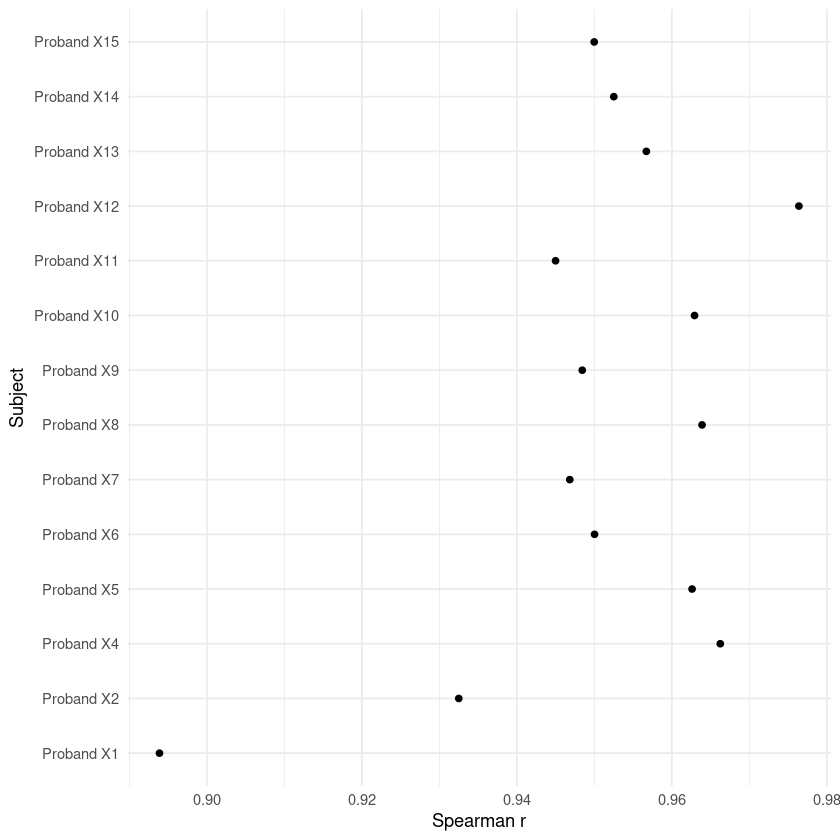

In [46]:
df3 |>
	ggplot(aes(y=Subject, x=`Spearman r`)) +
		geom_point()

In [49]:
ggsave("figures/supp_fig3.svg")
ggsave("figures/supp_fig3.png")

Saving 7 x 7 in image
Saving 7 x 7 in image
